# Fixing Blocked Obstruction Overlaps with RasFixit

This notebook demonstrates using the `RasFixit` module to automatically detect and repair overlapping blocked obstructions in HEC-RAS geometry files.

**Example Project:** HCFCD M3 Model A120-00-00 (Harris County Flood Control District)

## Overview

**Problem:** HEC-RAS geometry files sometimes contain overlapping or adjacent blocked obstructions, which cause model errors during geometry preprocessing.

**Solution:** `RasFixit.fix_blocked_obstructions()` automatically:
1. Detects overlapping/adjacent obstructions
2. Applies the elevation envelope algorithm (uses max elevation in overlap zones)
3. Inserts 0.02-unit gaps to prevent adjacency errors
4. Creates before/after PNG visualizations for engineering review
5. Creates timestamped backups

**Key Principle:** All fixes preserve hydraulic behavior by using the maximum (most restrictive) elevation in overlap zones.

## 1. Setup and Imports

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

from pathlib import Path  # Always import Path (needed throughout notebook)

if USE_LOCAL_SOURCE:
    import sys
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"📁 LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("📦 PIP PACKAGE MODE: Loading installed ras-commander")

# Import ras-commander
from ras_commander import RasFixit, FixResults, FixMessage, FixAction
from ras_commander.geom.GeomCrossSection import GeomCrossSection
from ras_commander.fixit import log_parser

# Additional imports for this notebook
import pandas as pd
import numpy as np
import shutil

# Verify which version loaded
import ras_commander
print(f"✓ Loaded: {ras_commander.__file__}")

📁 LOCAL SOURCE MODE: Loading from G:\GH\ras-commander/ras_commander


2026-05-08 11:26:07 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


✓ Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## Parameters

Configure these values to customize the notebook for your project.

In [2]:
# =============================================================================
# PARAMETERS - Edit these to customize the notebook
# =============================================================================
from pathlib import Path

# Project Configuration
#PROJECT_NAME = "Clear Creek"      # Example project to extract  NOT USED IN THIS NOTEBOOK
RAS_VERSION = "7.0"               # HEC-RAS version (6.3, 6.5, 6.6, etc.)

# Geometry Settings
GEOM_NUMBER = "01"                # Geometry file number
RIVER = "White"                   # River name for cross section queries
REACH = "West Fork"               # Reach name
CROSS_SECTION = "10457.31"        # Cross section station (RS)


In [3]:
# Download HCFCD M3 Model A (Clear Creek) containing A120-00-00 project
# This is a real-world project with known obstruction overlap issues
import zipfile
from ras_commander.sources.county import M3Model

# Step 1: Extract M3 Model 'A' (Clear Creek watershed)
print("Extracting M3 Model 'A' (Clear Creek)...")
m3_path = M3Model.extract_model('A')
print(f"✓ M3 Model extracted to: {m3_path}")

# Step 2: Find and extract A120-00-00 project ZIP
a120_zip = m3_path / "HEC-RAS" / "A120-00-00.zip"
a120_folder = m3_path / "HEC-RAS" / "A120-00-00"

if not a120_folder.exists():
    print(f"Extracting A120-00-00 project...")
    with zipfile.ZipFile(a120_zip, 'r') as zip_ref:
        zip_ref.extractall(a120_folder)
    print(f"✓ Project extracted to: {a120_folder}")
else:
    print(f"✓ Project already exists: {a120_folder}")

# Step 3: Set paths for this notebook
project_folder = a120_folder
geom_file = project_folder / "A120_00_00.g01"

print(f"\nProject folder: {project_folder}")
print(f"Geometry file exists: {geom_file.exists()}")

2026-05-08 11:26:09 - ras_commander.sources.county.m3_model - INFO - ----- M3Model Extracting Model -----


2026-05-08 11:26:09 - ras_commander.sources.county.m3_model - INFO - Extracting model 'A' - Clear Creek


2026-05-08 11:26:09 - ras_commander.sources.county.m3_model - INFO - Model 'Clear Creek' already exists at G:\GH\ras-commander\examples\m3_models\Clear Creek


2026-05-08 11:26:09 - ras_commander.sources.county.m3_model - INFO - Use overwrite=True to re-download


Extracting M3 Model 'A' (Clear Creek)...
✓ M3 Model extracted to: G:\GH\ras-commander\examples\m3_models\Clear Creek
✓ Project already exists: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00

Project folder: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00
Geometry file exists: True


In [4]:
# Detect overlaps without modifying the file
results = RasFixit.detect_obstruction_overlaps(geom_file)

print(f"Geometry File: {geom_file.name}")
print(f"Cross Sections Checked: {results.total_xs_checked}")
print(f"Cross Sections with Overlaps: {results.total_xs_fixed}")

if results.messages:
    print(f"\nAffected cross sections:")
    for msg in results.messages:
        print(f"  RS {msg.station}: {msg.original_count} obstructions -> would become {msg.fixed_count}")

2026-05-08 11:26:09 - ras_commander.geom.GeomCrossSection - WARNING - Expected 2 blocked obstructions, parsed 1


2026-05-08 11:26:09 - ras_commander.geom.GeomCrossSection - WARNING - Expected 3 blocked obstructions, parsed 2


Geometry File: A120_00_00.g01
Cross Sections Checked: 91
Cross Sections with Overlaps: 15

Affected cross sections:
  RS 20262.89: 5 obstructions -> would become 6
  RS 17853.49: 2 obstructions -> would become 2
  RS 17833.49: 2 obstructions -> would become 2
  RS 17612.53: 3 obstructions -> would become 3
  RS 15831.37: 2 obstructions -> would become 2
  RS 15136.2: 7 obstructions -> would become 8
  RS 14284.07: 3 obstructions -> would become 4
  RS 11422.31: 3 obstructions -> would become 4
  RS 11181.99: 3 obstructions -> would become 4
  RS 10150.51: 4 obstructions -> would become 5
  RS 10040.42: 4 obstructions -> would become 5
  RS 9960.36: 3 obstructions -> would become 4
  RS 5714.48: 2 obstructions -> would become 3
  RS 4894.121: 2 obstructions -> would become 2
  RS 4053.094: 2 obstructions -> would become 2


## 3. Examine the Overlapping Obstructions

Let's look at the detailed data for one of the affected cross sections.

In [5]:
# Look at first affected cross section in detail
if results.messages:
    msg = results.messages[0]
    
    print(f"=== Cross Section RS {msg.station} ===")
    print(f"\nOriginal Obstructions ({msg.original_count}):")
    for i, (start, end, elev) in enumerate(msg.original_data, 1):
        print(f"  {i}. Station {start:8.2f} to {end:8.2f}, Elevation: {elev:.2f}")
    
    print(f"\nFixed Obstructions ({msg.fixed_count}) - using max elevation envelope:")
    for i, (start, end, elev) in enumerate(msg.fixed_data, 1):
        print(f"  {i}. Station {start:8.2f} to {end:8.2f}, Elevation: {elev:.2f}")

=== Cross Section RS 20262.89 ===

Original Obstructions (5):
  1. Station  1771.46 to  2303.49, Elevation: 37.43
  2. Station  3165.57 to  4205.00, Elevation: 34.20
  3. Station  4825.70 to  5057.23, Elevation: 34.30
  4. Station  4850.00 to  5050.00, Elevation: 35.30
  5. Station  3100.00 to  3200.00, Elevation: 35.10

Fixed Obstructions (6) - using max elevation envelope:
  1. Station  1771.46 to  2303.49, Elevation: 37.43
  2. Station  3100.00 to  3200.00, Elevation: 35.10
  3. Station  3200.02 to  4205.00, Elevation: 34.20
  4. Station  4825.70 to  4850.00, Elevation: 34.30
  5. Station  4850.02 to  5050.00, Elevation: 35.30
  6. Station  5050.02 to  5057.23, Elevation: 34.30


## 4. Fix Overlapping Obstructions

Now let's apply the fixes. We'll work on a **copy** of the geometry file to preserve the original.

This will:
1. Create a timestamped backup of the file
2. Apply the elevation envelope algorithm to resolve overlaps
3. Generate before/after PNG visualizations
4. Return detailed results for engineering review

**IMPORTANT:** Always review the visualizations before accepting changes!

In [6]:
# Create a working copy so we don't modify the original
working_copy = project_folder / "A120_00_00_test_copy.g01"
shutil.copy(geom_file, working_copy)
print(f"Created working copy: {working_copy.name}")

# Fix overlapping obstructions with visualization
fix_results = RasFixit.fix_blocked_obstructions(
    working_copy,
    backup=True,       # Create timestamped backup
    visualize=True     # Generate before/after PNGs
)

print(f"\n=== Fix Results ===")
print(f"Cross Sections Checked: {fix_results.total_xs_checked}")
print(f"Cross Sections Fixed: {fix_results.total_xs_fixed}")
print(f"Backup Created: {fix_results.backup_path}")
print(f"Visualizations: {fix_results.visualization_folder}")

2026-05-08 11:26:09 - ras_commander.fixit.RasFixit - INFO - Created backup: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy.g01.backup_20260508_112609


2026-05-08 11:26:09 - ras_commander.fixit.RasFixit - INFO - Saving visualizations to: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy_g01_Obstructions_Fixed


Created working copy: A120_00_00_test_copy.g01


2026-05-08 11:26:09 - ras_commander.geom.GeomCrossSection - WARNING - Expected 2 blocked obstructions, parsed 1


2026-05-08 11:26:09 - ras_commander.geom.GeomCrossSection - WARNING - Expected 3 blocked obstructions, parsed 2


...

2026-05-08 11:26:13 - ras_commander.geom.GeomCrossSection - INFO - Updated blocked obstructions for A120-00-00/A120-00-00_0008/RS 4894.121: 2 obstructions written


2026-05-08 11:26:13 - ras_commander.geom.GeomParser - INFO - Successfully wrote geometry file: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy.g01


2026-05-08 11:26:13 - ras_commander.geom.GeomCrossSection - INFO - Updated blocked obstructions for A120-00-00/A120-00-00_0008/RS 4053.094: 2 obstructions written


2026-05-08 11:26:13 - ras_commander.fixit.RasFixit - INFO - Fixed 15 cross sections in A120_00_00_test_copy.g01



=== Fix Results ===
Cross Sections Checked: 91
Cross Sections Fixed: 15
Backup Created: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy.g01.backup_20260508_112609
Visualizations: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy_g01_Obstructions_Fixed


## 5. Review Fix Results

The `FixResults` object contains detailed information about every fix applied. Let's examine it.

In [7]:
# Convert results to DataFrame for easy analysis
df = fix_results.to_dataframe()
print(f"Fix Summary DataFrame ({len(df)} rows):")
print(df[['station', 'action', 'original_count', 'fixed_count', 'message']].to_string())

Fix Summary DataFrame (15 rows):
     station            action  original_count  fixed_count                                                   message
0   20262.89  OVERLAP_RESOLVED               5            6  Resolved 5 overlapping obstructions to 6 non-overlapping
1   17853.49  OVERLAP_RESOLVED               2            2  Resolved 2 overlapping obstructions to 2 non-overlapping
2   17833.49  OVERLAP_RESOLVED               2            2  Resolved 2 overlapping obstructions to 2 non-overlapping
3   17612.53  OVERLAP_RESOLVED               3            3  Resolved 3 overlapping obstructions to 3 non-overlapping
4   15831.37  OVERLAP_RESOLVED               2            2  Resolved 2 overlapping obstructions to 2 non-overlapping
5    15136.2  OVERLAP_RESOLVED               7            8  Resolved 7 overlapping obstructions to 8 non-overlapping
6   14284.07  OVERLAP_RESOLVED               3            4  Resolved 3 overlapping obstructions to 4 non-overlapping
7   11422.31  OVERLAP_R

In [8]:
# Export to CSV for documentation
csv_path = project_folder / "obstruction_fix_report.csv"
df.to_csv(csv_path, index=False)
print(f"Fix report exported to: {csv_path}")

Fix report exported to: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\obstruction_fix_report.csv


## 6. View Visualizations

The PNG visualizations show before/after comparisons for each fixed cross section. They are critical for engineering review.

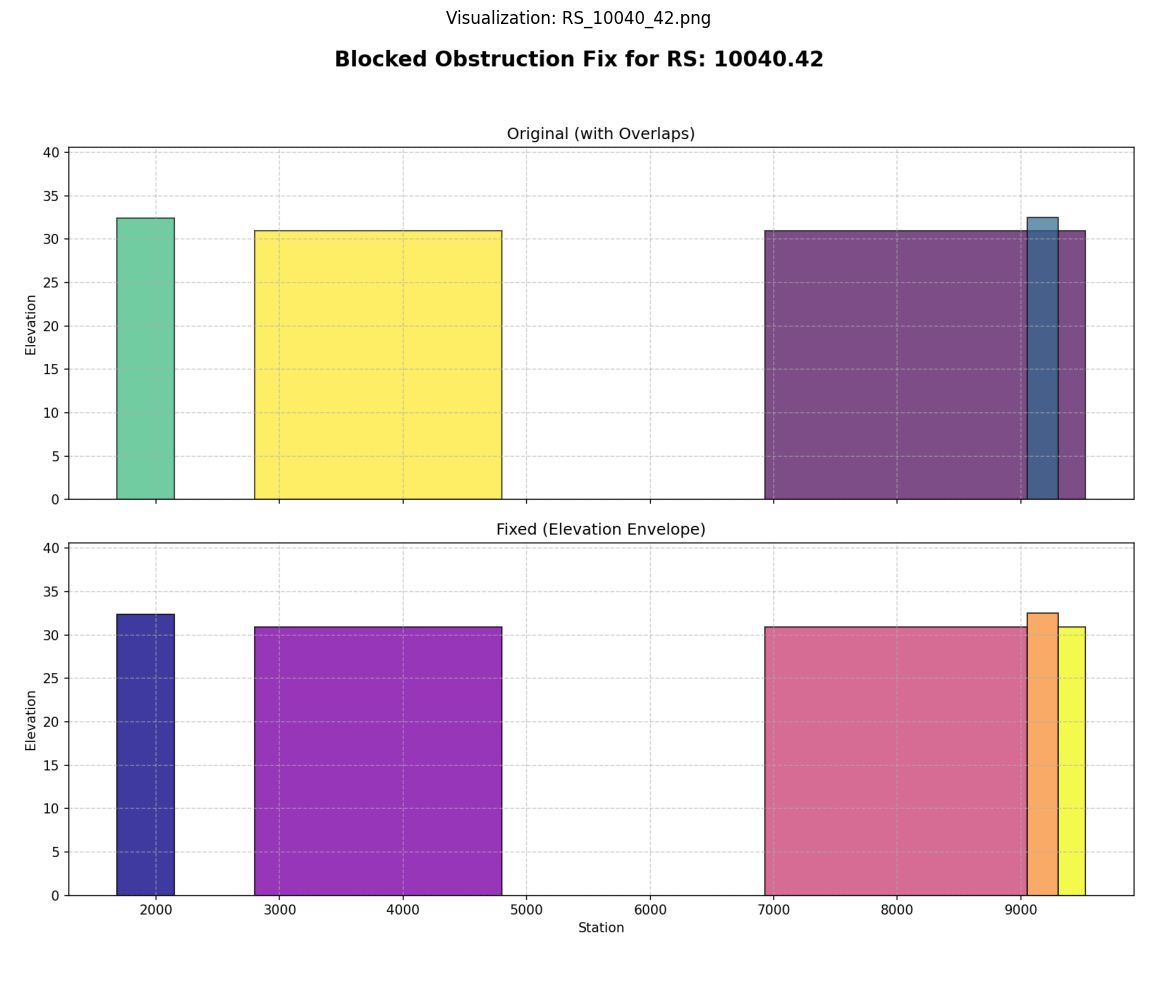


Total visualizations generated: 15
Location: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_test_copy_g01_Obstructions_Fixed


In [9]:
# Display a visualization (requires matplotlib)
import matplotlib.pyplot as plt
from matplotlib.image import imread

if fix_results.visualization_folder and fix_results.visualization_folder.exists():
    png_files = sorted(fix_results.visualization_folder.glob("*.png"))
    
    if png_files:
        # Display first visualization
        img = imread(png_files[0])
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Visualization: {png_files[0].name}")
        plt.tight_layout()
        plt.show()
        
        print(f"\nTotal visualizations generated: {len(png_files)}")
        print(f"Location: {fix_results.visualization_folder}")
    else:
        print("No PNG files found in visualization folder.")
else:
    print("No visualization folder available.")

In [10]:
# Display all visualizations (optional - may be slow for many cross sections)
show_all = False  # Set to True to view all

if show_all and fix_results.visualization_folder:
    png_files = sorted(fix_results.visualization_folder.glob("*.png"))
    
    for png_file in png_files:
        img = imread(png_file)
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(png_file.name)
        plt.tight_layout()
        plt.show()

## 7. Verify Fixes

After fixing, verify that no overlaps remain.

In [11]:
# Verify no overlaps remain after fix
verify_results = RasFixit.detect_obstruction_overlaps(working_copy)

if verify_results.total_xs_fixed == 0:
    print("SUCCESS: No overlapping obstructions remaining!")
    print(f"Verified {verify_results.total_xs_checked} cross sections.")
else:
    print(f"WARNING: {verify_results.total_xs_fixed} cross sections still have overlaps.")
    print("Please review the file manually.")

2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 2 blocked obstructions, parsed 1


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 3 blocked obstructions, parsed 2


SUCCESS: No overlapping obstructions remaining!
Verified 91 cross sections.


## 8. Log Parsing for Automated Workflows

The `log_parser` module can detect obstruction errors from HEC-RAS compute logs, enabling automated fix workflows.

In [12]:
# Example: Parse HEC-RAS log for obstruction errors
sample_log = """
HEC-RAS Model Computation
Processing cross section 20262.89
ERROR: Cross Section 20262.89 has overlapping blocked obstructions
Processing cross section 18765.43
ERROR: Blocked obstructions at station 18765.43 overlap or are adjacent
Computation complete with errors.
"""

# Detect errors
errors = log_parser.detect_obstruction_errors(sample_log)
print(f"Detected {len(errors)} obstruction errors")

# Extract affected stations
stations = log_parser.extract_cross_section_ids(sample_log)
print(f"Affected stations: {stations}")

# Generate human-readable report
print("\n" + log_parser.generate_error_report(errors))

Detected 2 obstruction errors
Affected stations: ['18765.43', '20262.89']

BLOCKED OBSTRUCTION ERROR REPORT

Total Errors Found: 2


OVERLAP (1 occurrences):
--------------------------------------------------------------------------------
  River Station: 20262.89
  Line: 4
  Message: ERROR: Cross Section 20262.89 has overlapping blocked obstructions


ADJACENT (1 occurrences):
--------------------------------------------------------------------------------
  River Station: 18765.43
  Line: 6
  Message: ERROR: Blocked obstructions at station 18765.43 overlap or are adjacent



In [13]:
# Automated workflow: Detect errors from log, then fix geometry files
def auto_fix_workflow(log_file_path, project_dir):
    """Automated workflow to detect and fix obstruction errors."""
    
    # Step 1: Check log for errors
    if not log_parser.has_obstruction_errors(log_file_path):
        print("No obstruction errors found in log.")
        return None
    
    # Step 2: Read log and detect errors
    with open(log_file_path, 'r') as f:
        log_content = f.read()
    
    errors = log_parser.detect_obstruction_errors(log_content)
    print(f"Found {len(errors)} obstruction errors")
    
    # Step 3: Find geometry files in project
    geom_files = log_parser.find_geometry_files_in_directory(project_dir)
    print(f"Found {len(geom_files)} geometry files")
    
    # Step 4: Fix each geometry file
    all_results = {}
    for geom_path in geom_files:
        results = RasFixit.fix_blocked_obstructions(
            geom_path,
            backup=True,
            visualize=True
        )
        all_results[geom_path] = results
        print(f"  Fixed {results.total_xs_fixed} cross sections in {Path(geom_path).name}")
    
    return all_results

print("auto_fix_workflow() function defined.")
print("Usage: auto_fix_workflow('compute.log', 'path/to/project')")

auto_fix_workflow() function defined.
Usage: auto_fix_workflow('compute.log', 'path/to/project')


## 9. GeomCrossSection Blocked Obstruction API

The `GeomCrossSection` class exposes low-level read/write methods for blocked obstructions, independent of the `RasFixit` repair workflow. Use these when you need to:

- **Inspect** obstruction data across all cross sections as a DataFrame
- **Programmatically write** new or modified obstructions to a `.g##` file
- **Cross-validate** text-parsed obstructions against HDF geometry flags

These methods follow ras-commander API conventions: `@staticmethod`, `@log_call`, and accept either a geometry number with `ras_object` or a direct file path.

### 9a. Read Blocked Obstructions as a DataFrame

`get_blocked_obstructions()` returns a DataFrame with `xs_id`, `River`, `Reach`, `RS`, `obstruction_index`, `start_sta`, `end_sta`, and `elevation` columns. Pass no `xs_id` to read all cross sections, or pass a specific identifier to filter.

In [14]:
# Read all blocked obstructions from the original geometry file
all_obs = GeomCrossSection.get_blocked_obstructions(geom_file)

print(f"Total obstructions across all cross sections: {len(all_obs)}")
print(f"Cross sections with obstructions: {all_obs['xs_id'].nunique()}")
print(f"\nColumns: {list(all_obs.columns)}")
print(f"\nFirst 10 rows:")
all_obs.head(10)

2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 2 blocked obstructions, parsed 1


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 3 blocked obstructions, parsed 2


Total obstructions across all cross sections: 178
Cross sections with obstructions: 72

Columns: ['xs_id', 'River', 'Reach', 'RS', 'obstruction_index', 'start_sta', 'end_sta', 'elevation']

First 10 rows:


,xs_id,River,Reach,RS,obstruction_index,start_sta,end_sta,elevation
0,A120-00-00|A120-00-00_0008|29113.3,A120-00-00,A120-00-00_0008,29113.3,0,5240.00,5875.00,40.5
1,A120-00-00|A120-00-00_0008|28913.21,A120-00-00,A120-00-00_0008,28913.21,0,5193.17,5481.91,41.0
2,A120-00-00|A120-00-00_0008|28022.89,A120-00-00,A120-00-00_0008,28022.89,0,3200.00,3400.00,41.0
3,A120-00-00|A120-00-00_0008|28022.89,A120-00-00,A120-00-00_0008,28022.89,1,3571.00,4500.00,39.6
4,A120-00-00|A120-00-00_0008|28022.89,A120-00-00,A120-00-00_0008,28022.89,2,5200.00,5900.00,41.0
5,A120-00-00|A120-00-00_0008|27857.47,A120-00-00,A120-00-00_0008,27857.47,0,2900.00,3150.00,41.0
6,A120-00-00|A120-00-00_0008|27857.47,A120-00-00,A120-00-00_0008,27857.47,1,3151.00,4300.00,39.5
7,A120-00-00|A120-00-00_0008|26578.6,A120-00-00,A120-00-00_0008,26578.6,0,-500.00,-180.00,41.0
8,A120-00-00|A120-00-00_0008|26578.6,A120-00-00,A120-00-00_0008,26578.6,1,-150.00,2300.00,39.4
9,A120-00-00|A120-00-00_0008|25646.24,A120-00-00,A120-00-00_0008,25646.24,0,-350.00,0.00,40.5


In [15]:
# Read obstructions for a single cross section using xs_id
target_xs = all_obs["xs_id"].iloc[0]
single_xs_obs = GeomCrossSection.get_blocked_obstructions(geom_file, xs_id=target_xs)

print(f"Obstructions for {target_xs}:")
for _, row in single_xs_obs.iterrows():
    print(f"  [{row['obstruction_index']}] Station {row['start_sta']:8.2f} to {row['end_sta']:8.2f}, Elevation: {row['elevation']:.2f}")

# Summary statistics
print(f"\nSummary across all cross sections:")
summary = all_obs.groupby("xs_id").agg(
    count=("obstruction_index", "count"),
    min_sta=("start_sta", "min"),
    max_sta=("end_sta", "max"),
    min_elev=("elevation", "min"),
    max_elev=("elevation", "max"),
).reset_index()
summary

Obstructions for A120-00-00|A120-00-00_0008|29113.3:
  [0] Station  5240.00 to  5875.00, Elevation: 40.50

Summary across all cross sections:


,xs_id,count,min_sta,max_sta,min_elev,max_elev
0,A120-00-00|A120-00-00_0008|10040.42,4,1685.00,9522.18,30.95,32.50
1,A120-00-00|A120-00-00_0008|10150.51,4,898.75,9450.97,31.00,32.67
2,A120-00-00|A120-00-00_0008|10170.53,4,1205.92,9350.00,31.00,32.99
3,A120-00-00|A120-00-00_0008|11181.99,3,1200.00,11118.41,31.25,32.70
4,A120-00-00|A120-00-00_0008|11422.31,3,1200.00,11836.18,31.35,33.10
...,...,...,...,...,...,...
67,A120-00-00|A120-00-00_0008|9291.765,2,2650.00,8000.00,30.65,30.65
68,A120-00-00|A120-00-00_0008|9331.771,3,2350.00,8700.00,30.70,30.70
69,A120-00-00|A120-00-00_0008|9392.3,4,2450.00,9608.65,30.80,32.67
70,A120-00-00|A120-00-00_0008|9402.438,5,2500.00,9900.00,30.80,32.85


### 9b. Write Blocked Obstructions (Round-Trip)

`set_blocked_obstructions()` writes obstruction data to a specific cross section. It accepts `BlockedObstruction` objects, DataFrames, dicts, or `(start_sta, end_sta, elevation)` tuples. A backup is created by default.

Here we demonstrate a read-modify-write round trip: read the original obstructions, shift elevations up by 1 foot, write them back, and verify the round trip.

In [16]:
# Create a fresh working copy for the write demo
write_demo_copy = project_folder / "A120_00_00_write_demo.g01"
shutil.copy(geom_file, write_demo_copy)

# Read original obstructions for a specific cross section
target_xs = all_obs["xs_id"].iloc[0]
original = GeomCrossSection.get_blocked_obstructions(write_demo_copy, xs_id=target_xs)
print(f"Original obstructions for {target_xs}:")
print(original[["start_sta", "end_sta", "elevation"]].to_string(index=False))

# Modify: shift all elevations up by 1 foot
modified = original[["start_sta", "end_sta", "elevation"]].copy()
modified["elevation"] = modified["elevation"] + 1.0

print(f"\nModified obstructions (elevation + 1.0 ft):")
print(modified.to_string(index=False))

# Write the modified obstructions back
backup_path = GeomCrossSection.set_blocked_obstructions(
    write_demo_copy,
    xs_id=target_xs,
    obstructions=modified,
)
print(f"\nBackup created: {backup_path.name}")

Original obstructions for A120-00-00|A120-00-00_0008|29113.3:


2026-05-08 11:26:14 - ras_commander.geom.GeomParser - INFO - Created backup: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_write_demo.g01.bak


 start_sta  end_sta  elevation
    5240.0   5875.0       40.5

Modified obstructions (elevation + 1.0 ft):
 start_sta  end_sta  elevation
    5240.0   5875.0       41.5


2026-05-08 11:26:14 - ras_commander.geom.GeomParser - INFO - Successfully wrote geometry file: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_write_demo.g01


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - INFO - Updated blocked obstructions for A120-00-00/A120-00-00_0008/RS 29113.3: 1 obstructions written



Backup created: A120_00_00_write_demo.g01.bak


In [17]:
# Verify the round trip: re-read and compare
roundtrip = GeomCrossSection.get_blocked_obstructions(write_demo_copy, xs_id=target_xs)

print("Round-trip verification:")
print(roundtrip[["start_sta", "end_sta", "elevation"]].to_string(index=False))

# Check values match
assert np.allclose(roundtrip["start_sta"].values, modified["start_sta"].values), "start_sta mismatch"
assert np.allclose(roundtrip["end_sta"].values, modified["end_sta"].values), "end_sta mismatch"
assert np.allclose(roundtrip["elevation"].values, modified["elevation"].values), "elevation mismatch"
print(f"\n✓ Round trip verified: {len(roundtrip)} obstructions match")

# Verify other cross sections were not affected
all_obs_after = GeomCrossSection.get_blocked_obstructions(write_demo_copy)
other_xs_before = all_obs[all_obs["xs_id"] != target_xs]
other_xs_after = all_obs_after[all_obs_after["xs_id"] != target_xs]

assert len(other_xs_before) == len(other_xs_after), "Other XS obstruction count changed!"
assert np.allclose(
    other_xs_before["elevation"].values,
    other_xs_after["elevation"].values,
), "Other XS elevations changed!"
print(f"✓ Other cross sections unaffected ({len(other_xs_after)} obstructions unchanged)")

2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 2 blocked obstructions, parsed 1


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - WARNING - Expected 3 blocked obstructions, parsed 2


Round-trip verification:
 start_sta  end_sta  elevation
    5240.0   5875.0       41.5

✓ Round trip verified: 1 obstructions match
✓ Other cross sections unaffected (177 obstructions unchanged)


### 9c. Insert New Obstructions and Remove Existing Ones

`set_blocked_obstructions()` can also insert a new obstruction block into a cross section that has none, or remove all obstructions by passing an empty list.

In [18]:
# Find a cross section that has NO obstructions
xs_df = GeomCrossSection.get_cross_sections(write_demo_copy)
xs_with_obs = set(all_obs["xs_id"].unique())
all_xs_ids = [
    GeomCrossSection._make_xs_id(row["River"], row["Reach"], row["RS"])
    for _, row in xs_df.iterrows()
]
xs_without_obs = [xid for xid in all_xs_ids if xid not in xs_with_obs]

if xs_without_obs:
    insert_target = xs_without_obs[0]
    print(f"Cross section with no obstructions: {insert_target}")

    # Insert new obstructions using tuples
    new_obs = [
        (100.0, 200.0, 50.0),
        (300.0, 400.0, 55.0),
    ]
    GeomCrossSection.set_blocked_obstructions(
        write_demo_copy, xs_id=insert_target, obstructions=new_obs, create_backup=False,
    )

    # Verify insertion
    inserted = GeomCrossSection.get_blocked_obstructions(write_demo_copy, xs_id=insert_target)
    print(f"Inserted {len(inserted)} obstructions:")
    print(inserted[["start_sta", "end_sta", "elevation"]].to_string(index=False))

    # Now remove them by passing an empty list
    GeomCrossSection.set_blocked_obstructions(
        write_demo_copy, xs_id=insert_target, obstructions=[], create_backup=False,
    )
    removed = GeomCrossSection.get_blocked_obstructions(write_demo_copy, xs_id=insert_target)
    print(f"\nAfter removal: {len(removed)} obstructions (block deleted from file)")
else:
    print("All cross sections have obstructions in this geometry.")

2026-05-08 11:26:14 - ras_commander.geom.GeomParser - INFO - Successfully wrote geometry file: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_write_demo.g01


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - INFO - Updated blocked obstructions for A120-00-00/A120-00-00_0008/RS 25548: 2 obstructions written


2026-05-08 11:26:14 - ras_commander.geom.GeomParser - INFO - Successfully wrote geometry file: G:\GH\ras-commander\examples\m3_models\Clear Creek\HEC-RAS\A120-00-00\A120_00_00_write_demo.g01


2026-05-08 11:26:14 - ras_commander.geom.GeomCrossSection - INFO - Updated blocked obstructions for A120-00-00/A120-00-00_0008/RS 25548: 0 obstructions written


Cross section with no obstructions: A120-00-00|A120-00-00_0008|25548
Inserted 2 obstructions:
 start_sta  end_sta  elevation
     100.0    200.0       50.0
     300.0    400.0       55.0

After removal: 0 obstructions (block deleted from file)


### 9d. HDF Cross-Validation

`validate_blocked_obstructions_hdf()` compares text-parsed `#Block Obstruct=` presence against the HDF geometry's `Obstr Block Mode` flag per cross section. This catches text/HDF drift after manual edits.

**Note:** This requires a preprocessed `.g##.hdf` file alongside the text geometry. The M3 model used in this notebook does not include a preprocessed HDF, so we show the API signature below.

In [19]:
# HDF cross-validation (requires preprocessed .g##.hdf file)
hdf_file = Path(str(geom_file) + ".hdf")

if hdf_file.exists():
    validation = GeomCrossSection.validate_blocked_obstructions_hdf(geom_file)
    mismatches = validation[~validation["matches_hdf"]]
    print(f"Validated {len(validation)} cross sections against HDF")
    print(f"Mismatches: {len(mismatches)}")
    if len(mismatches) > 0:
        print(mismatches[["xs_id", "text_obstruction_count", "hdf_obstr_block_mode", "matches_hdf"]])
    else:
        print("All text/HDF obstruction flags agree.")
else:
    print(f"No HDF file found at {hdf_file.name}")
    print("To use HDF validation, preprocess the geometry in HEC-RAS first.")
    print()
    print("Usage:")
    print("  validation = GeomCrossSection.validate_blocked_obstructions_hdf(geom_file)")
    print("  validation = GeomCrossSection.validate_blocked_obstructions_hdf(geom_file, hdf_path='custom.hdf')")
    print()
    print("Returns a DataFrame with columns:")
    print("  xs_id, River, Reach, RS, text_obstruction_count,")
    print("  text_has_blocked_obstructions, hdf_obstr_block_mode,")
    print("  hdf_has_blocked_obstructions, matches_hdf")

No HDF file found at A120_00_00.g01.hdf
To use HDF validation, preprocess the geometry in HEC-RAS first.

Usage:
  validation = GeomCrossSection.validate_blocked_obstructions_hdf(geom_file)
  validation = GeomCrossSection.validate_blocked_obstructions_hdf(geom_file, hdf_path='custom.hdf')

Returns a DataFrame with columns:
  xs_id, River, Reach, RS, text_obstruction_count,
  text_has_blocked_obstructions, hdf_obstr_block_mode,
  hdf_has_blocked_obstructions, matches_hdf


## 10. Cleanup (Optional)

Remove test files after verification.

In [20]:
# Optional: Clean up test files
cleanup = True  # Set to False to keep test files

if cleanup:
    # Remove working copy
    if working_copy.exists():
        working_copy.unlink()
        print(f"Removed: {working_copy.name}")
    
    # Remove backup
    if fix_results.backup_path and fix_results.backup_path.exists():
        fix_results.backup_path.unlink()
        print(f"Removed backup: {fix_results.backup_path.name}")
    
    # Remove visualization folder
    if fix_results.visualization_folder and fix_results.visualization_folder.exists():
        shutil.rmtree(fix_results.visualization_folder)
        print(f"Removed visualization folder: {fix_results.visualization_folder.name}")
    
    # Remove CSV report
    if csv_path.exists():
        csv_path.unlink()
        print(f"Removed: {csv_path.name}")

    # Remove write demo copy and its backup
    if write_demo_copy.exists():
        write_demo_copy.unlink()
        print(f"Removed: {write_demo_copy.name}")
    for bak in project_folder.glob("A120_00_00_write_demo.g01.bak*"):
        bak.unlink()
        print(f"Removed backup: {bak.name}")
    
    print("\nCleanup complete!")
else:
    print("Cleanup skipped. Set cleanup=True to remove test files.")

Removed: A120_00_00_test_copy.g01
Removed backup: A120_00_00_test_copy.g01.backup_20260508_112609
Removed visualization folder: A120_00_00_test_copy_g01_Obstructions_Fixed
Removed: obstruction_fix_report.csv
Removed: A120_00_00_write_demo.g01
Removed backup: A120_00_00_write_demo.g01.bak

Cleanup complete!


## Summary

This notebook demonstrated:

**Detection & Repair (RasFixit):**
- `RasFixit.detect_obstruction_overlaps()` - Non-destructive scan for overlaps
- `RasFixit.fix_blocked_obstructions()` - Apply elevation envelope algorithm
  - `backup=True` creates timestamped backups
  - `visualize=True` generates before/after PNGs
  - `dry_run=True` detects without modifying

**Low-Level Read/Write (GeomCrossSection):**
- `GeomCrossSection.get_blocked_obstructions()` - Read obstructions as DataFrame (all XS or filtered)
- `GeomCrossSection.set_blocked_obstructions()` - Write/update/insert/remove obstructions per XS
- `GeomCrossSection.validate_blocked_obstructions_hdf()` - Cross-check text vs HDF flags

**Log Parsing:**
- `log_parser.detect_obstruction_errors()` - Parse HEC-RAS logs
- `log_parser.find_geometry_files_in_directory()` - Find .g## files
- `log_parser.generate_error_report()` - Human-readable report

**Results:**
- `FixResults.to_dataframe()` - Export to pandas DataFrame
- `FixMessage` contains original and fixed data for audit trail

### Engineering Review Requirements

**IMPORTANT:** All fixes should be reviewed by a licensed professional engineer before accepting changes to production models.

The visualization outputs provide an audit trail showing:
- Original obstruction configuration
- Fixed obstruction configuration
- Algorithm decisions made

### Algorithm Details

The elevation envelope algorithm:
1. Collects all critical stations (start/end of each obstruction)
2. For each segment between stations, uses **maximum elevation** (most restrictive)
3. Merges adjacent segments with same elevation
4. Inserts **0.02-unit gaps** where different elevations meet (HEC-RAS requirement)

This is **hydraulically conservative** - it preserves flow restrictions in overlap zones.

### Example Project

This notebook uses the HCFCD M3 Model A120-00-00 (Harris County Flood Control District), which contains real-world blocked obstruction issues in 15 of its 91 cross sections.